# Adult Income Prediction using Decision Tree, Bagging and Random Forest

## Project Objective

The objective of this project is to predict whether an individual's annual income exceeds \$50,000 using demographic and employment-related attributes. The project compares the performance of Decision Tree, Bagging, and Random Forest classifiers, and analyzes the impact of ensemble learning, cross-validation, hyperparameter tuning, and feature importance on model performance.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [64]:
columns = [
    "age",
    "workclass",
    "fnlwgt",
    "education",
    "education_num",
    "marital_status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "capital_gain",
    "capital_loss",
    "hours_per_week",
    "native_country",
    "income"
]
df=pd.read_csv(
    "adult/adult.data",
    header=None,
    names=columns,
    skipinitialspace=True
)
df

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [65]:
df.shape

(32561, 15)

In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  int64 
 13  native_country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [67]:
df.duplicated().sum()

np.int64(24)

In [68]:
(df == "?").sum()

age                  0
workclass         1836
fnlwgt               0
education            0
education_num        0
marital_status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital_gain         0
capital_loss         0
hours_per_week       0
native_country     583
income               0
dtype: int64

In [69]:
df = df.drop_duplicates()

In [70]:
df = df[df["workclass"] != "?"]
df = df[df["occupation"] != "?"]
df = df[df["native_country"] != "?"]

In [71]:
df.shape

(30139, 15)

In [72]:
df["income"].value_counts(normalize=True) * 100

income
<=50K    75.095391
>50K     24.904609
Name: proportion, dtype: float64

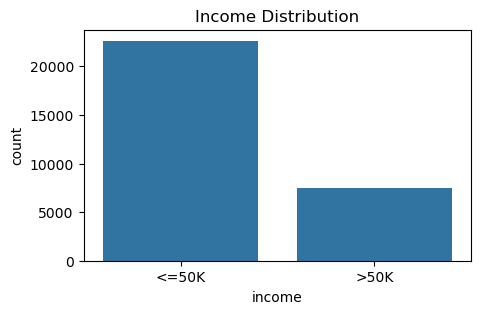

In [73]:
plt.figure(figsize=(5,3))
sns.countplot(x="income", data=df)

plt.title("Income Distribution")
plt.show()

##### Observation

The dataset is imbalanced.
Approximately 75% of individuals earn <=50K,
while only 25% earn >50K.

Therefore, model evaluation should not rely solely on accuracy.
Metrics such as Precision, Recall, and F1-score will also be considered.

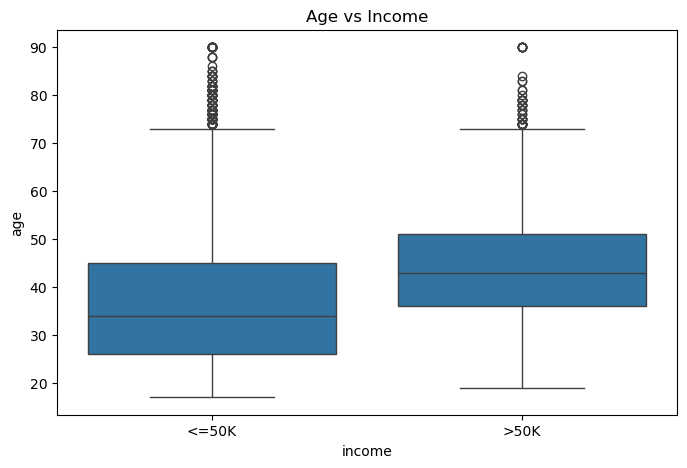

In [74]:
plt.figure(figsize=(8,5))
sns.boxplot(x="income", y="age", data=df)
plt.title("Age vs Income")
plt.show()

#### Observation

Individuals earning more than 50K generally have a higher median age.
This suggests that age may be an important predictor of income and could contribute significantly to tree-based models.

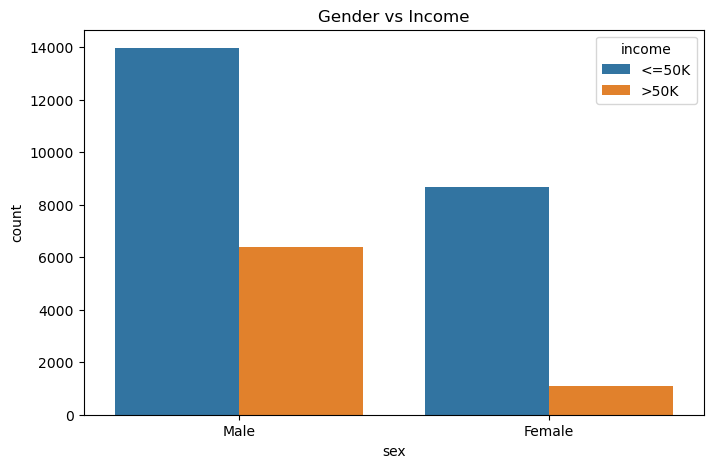

In [75]:
plt.figure(figsize=(8,5))
sns.countplot(x="sex", hue="income", data=df)
plt.title("Gender vs Income")
plt.show()

In [76]:
pd.crosstab(
    df["sex"],
    df["income"],
    normalize="index"
) * 100

income,<=50K,>50K
sex,,
Female,88.621713,11.378287
Male,68.604537,31.395463


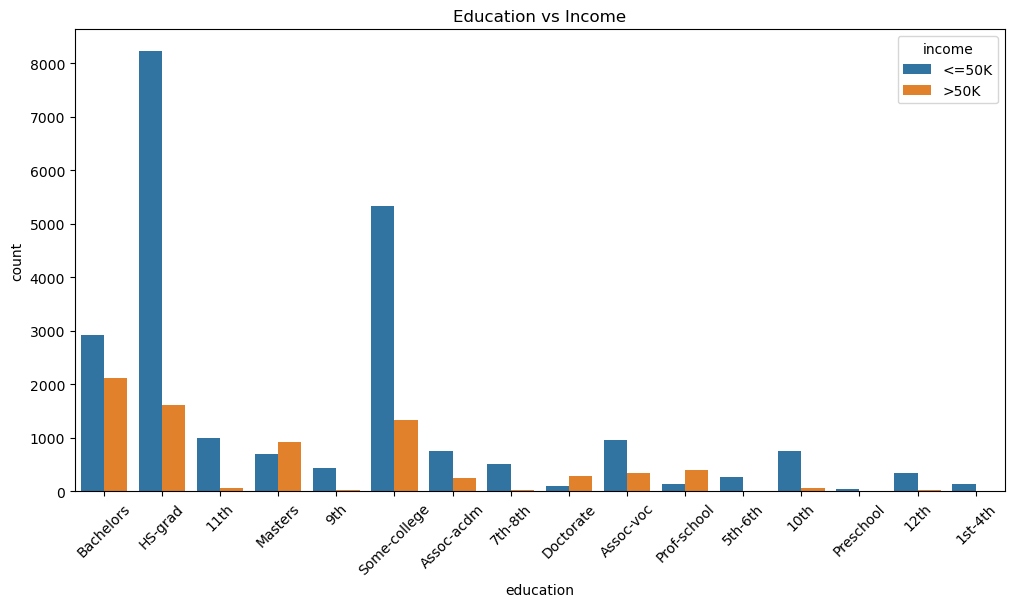

In [77]:
plt.figure(figsize=(12,6))

sns.countplot(
    x="education",
    hue="income",
    data=df
)
plt.xticks(rotation=45)
plt.title("Education vs Income")
plt.show()

In [78]:
pd.crosstab(
    df["education"],
    df["income"],
    normalize="index"
) *100

income,<=50K,>50K
education,,
10th,92.804878,7.195122
11th,94.370229,5.629771
12th,92.307692,7.692308
1st-4th,95.973154,4.026846
5th-6th,95.818815,4.181185
7th-8th,93.705036,6.294964
9th,94.505495,5.494505
Assoc-acdm,74.603175,25.396825
Assoc-voc,73.680184,26.319816


## Preparing Data for Modeling


In [79]:
df.select_dtypes(include="object").columns

Index(['workclass', 'education', 'marital_status', 'occupation',
       'relationship', 'race', 'sex', 'native_country', 'income'],
      dtype='object')

In [80]:
df["income"]=df["income"].map({
    "<=50K":0,
    ">50K":1
})

In [81]:
df["income"].value_counts()

income
0    22633
1     7506
Name: count, dtype: int64

In [82]:
X=df.drop("income",axis=1)
y=df["income"]

In [83]:
#one-hot encoding
X=pd.get_dummies(X,drop_first=True)
X.head()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week,workclass_Local-gov,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,...,native_country_Portugal,native_country_Puerto-Rico,native_country_Scotland,native_country_South,native_country_Taiwan,native_country_Thailand,native_country_Trinadad&Tobago,native_country_United-States,native_country_Vietnam,native_country_Yugoslavia
0,39,77516,13,2174,0,40,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1,50,83311,13,0,0,13,False,False,False,True,...,False,False,False,False,False,False,False,True,False,False
2,38,215646,9,0,0,40,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
3,53,234721,7,0,0,40,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
4,28,338409,13,0,0,40,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False


In [84]:
X.shape

(30139, 96)

In [85]:
(df == "?").sum().sum()

np.int64(0)

# Decision Tree

In [87]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,y,
    test_size=0.2,
    random_state=42
)

In [88]:
from sklearn.tree import DecisionTreeClassifier
dt=DecisionTreeClassifier(
    random_state=42
)

In [91]:
dt.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [92]:
y_pred_dt=dt.predict(X_test)

In [93]:
from sklearn.metrics import accuracy_score
accuracy_score(y_pred_dt,y_test)

0.814200398142004

In [100]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_pred_dt)
cm

array([[3915,  570],
       [ 550,  993]])

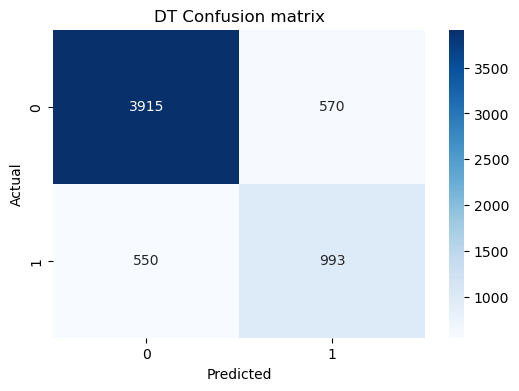

In [95]:
plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("DT Confusion matrix")
plt.show()

In [99]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred_dt))

              precision    recall  f1-score   support

           0       0.88      0.87      0.87      4485
           1       0.64      0.64      0.64      1543

    accuracy                           0.81      6028
   macro avg       0.76      0.76      0.76      6028
weighted avg       0.82      0.81      0.81      6028



The model is much better at prediction <=50K then >50K because of the dataset imbalance.

In [102]:
print(dt.score(X_train, y_train))
print(dt.score(X_test, y_test))

0.9999585251544938
0.814200398142004


This is overfitting. To reduce this we will be doing using Bagging and Random Forest.

# Bagging

In [106]:
from sklearn.ensemble import BaggingClassifier

bagging=BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

In [107]:
bagging.fit(X_train,y_train)

,estimator,DecisionTreeClassifier()
,n_estimators,100
,max_samples,1.0
,max_features,1.0
,bootstrap,True
,bootstrap_features,False
,oob_score,False
,warm_start,False
,n_jobs,-1
,random_state,42
,verbose,0


In [108]:
y_pred_bag=bagging.predict(X_test)

In [109]:
accuracy_score(y_test,y_pred_bag)

0.8578301260783012

In [110]:
print("Train Accuracy:", bagging.score(X_train, y_train))
print("Test Accuracy :", bagging.score(X_test, y_test))

Train Accuracy: 0.9999170503089876
Test Accuracy : 0.8578301260783012


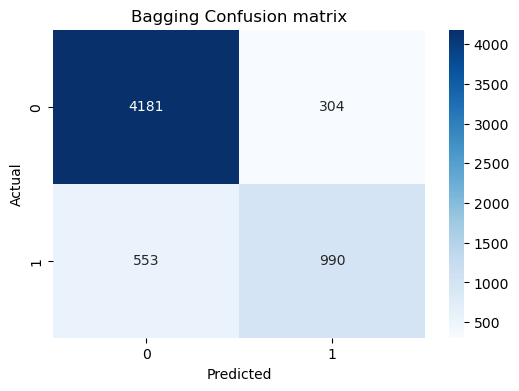

In [120]:
cm_bag=confusion_matrix(y_test,y_pred_bag)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm_bag,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Bagging Confusion matrix")
plt.show()

In [121]:
print(classification_report(y_test, y_pred_bag))

              precision    recall  f1-score   support

           0       0.88      0.93      0.91      4485
           1       0.77      0.64      0.70      1543

    accuracy                           0.86      6028
   macro avg       0.82      0.79      0.80      6028
weighted avg       0.85      0.86      0.85      6028



Bagging outperformed a single Decision Tree across all major evaluation metrics.

The ensemble reduced overfitting and improved generalization, resulting in higher accuracy and a significantly better F1-score for the >50K income class.

# Random Forest

In [122]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

In [123]:
rf.fit(X_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [124]:
y_pred_rf=rf.predict(X_test)

In [125]:
accuracy_score(y_test,y_pred_rf)

0.8565029860650298

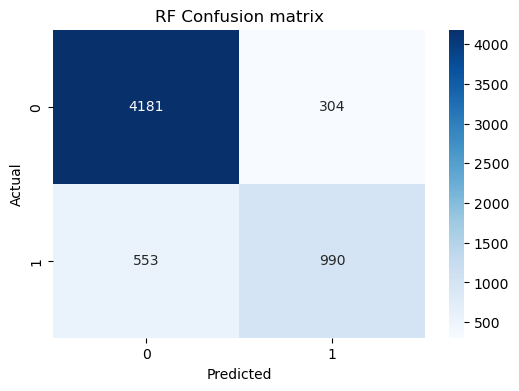

In [126]:
cm_rf=confusion_matrix(y_test,y_pred_bag)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("RF Confusion matrix")
plt.show()

In [127]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.88      0.93      0.91      4485
           1       0.76      0.64      0.70      1543

    accuracy                           0.86      6028
   macro avg       0.82      0.79      0.80      6028
weighted avg       0.85      0.86      0.85      6028



In [128]:
print("Train Accuracy:", rf.score(X_train, y_train))
print("Test Accuracy :", rf.score(X_test, y_test))

Train Accuracy: 0.9999170503089876
Test Accuracy : 0.8565029860650298


Bagging and Random Forest have smilar result and are better than Decision Tree as of now

# Cross Validation

In [130]:
from sklearn.model_selection import cross_val_score

In [131]:
dt_cv = cross_val_score(
    dt,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print(dt_cv)
print(dt_cv.mean())

[0.80059721 0.80590577 0.80922362 0.82067021 0.81383773]
0.8100469090156011


In [133]:
bag_cv = cross_val_score(
    bagging,
    X,
    y,
    cv=5,
    scoring="accuracy"
)
print(bag_cv)
print(bag_cv.mean())

[0.84538819 0.84472462 0.84870604 0.85683477 0.85017422]
0.8491655664968822


In [135]:
rf_cv = cross_val_score(
    rf,
    X,
    y,
    cv=5,
    scoring="accuracy"
)
print(rf_cv)
print(rf_cv.mean())

[0.84903782 0.84406105 0.84704711 0.85700066 0.8524971 ]
0.8499287490742005


### Observations
Decision Tree suffered from severe overfitting, achieving nearly perfect training accuracy but significantly lower test accuracy.

Both Bagging and Random Forest substantially improved generalization performance.

Random Forest achieved the highest cross-validation accuracy, while Bagging achieved the highest test-set accuracy. Since the difference between the two ensemble methods was very small, both can be considered strong performers on this dataset.

In [137]:
#feature imp for rf
feature_importance=pd.DataFrame({
    "Feature":X.columns,
    "Importance":rf.feature_importances_
})
feature_importance=feature_importance.sort_values(
    by="Importance",
    ascending=False
)
feature_importance.head(10)

,Feature,Importance
1,fnlwgt,0.164909
0,age,0.154633
3,capital_gain,0.100527
5,hours_per_week,0.085161
28,marital_status_Married-civ-spouse,0.080879
2,education_num,0.059167
4,capital_loss,0.033517
30,marital_status_Never-married,0.029362
55,sex_Male,0.019978
35,occupation_Exec-managerial,0.019710


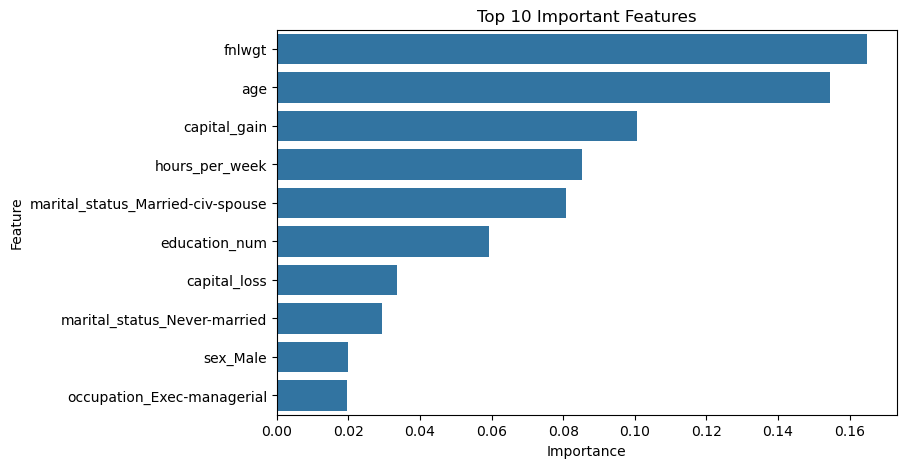

In [139]:
top10 = feature_importance.head(10)

plt.figure(figsize=(8,5))

sns.barplot(
    x="Importance",
    y="Feature",
    data=top10
)

plt.title("Top 10 Important Features")
plt.show()

# Hyperparameter Tuning

In [140]:
from sklearn.model_selection import GridSearchCV
param_grid={
    "n_estimators":[100,200],
    "max_depth":[10,20,None],
    "min_samples_split":[2,5]
}

In [141]:
grid_rf=GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

In [142]:
grid_rf.fit(X_train,y_train)

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [10, 20, ...], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


In [143]:
print(grid_rf.best_params_)
print(grid_rf.best_score_)

{'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 200}
0.8583219277508191


In [144]:
best_rf = grid_rf.best_estimator_
y_pred_best = best_rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))

Accuracy: 0.8611479761114798
              precision    recall  f1-score   support

           0       0.87      0.95      0.91      4485
           1       0.81      0.60      0.69      1543

    accuracy                           0.86      6028
   macro avg       0.84      0.77      0.80      6028
weighted avg       0.86      0.86      0.85      6028



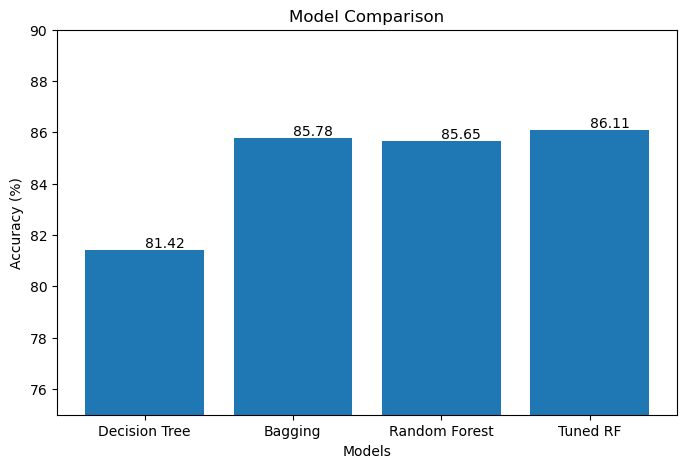

In [152]:
models = [
    "Decision Tree",
    "Bagging",
    "Random Forest",
    "Tuned RF"
]

accuracies = [
    81.42,
    85.78,
    85.65,
    86.11
]

plt.figure(figsize=(8,5))

plt.bar(models, accuracies)

plt.ylabel("Accuracy (%)")
plt.xlabel("Models")
plt.title("Model Comparison")

plt.ylim(75, 90)

for i, v in enumerate(accuracies):
    plt.text(i, v + 0.1, str(v))

plt.show()

A comparative study of Decision Tree, Bagging, and Random Forest classifiers was performed on the Adult Income dataset.

The Decision Tree achieved high training accuracy but suffered from significant overfitting.

Bagging substantially improved generalization performance by aggregating multiple decision trees trained on bootstrap samples.

Random Forest further improved performance through random feature selection and ensemble learning. Hyperparameter tuning using GridSearchCV resulted in the best overall model with a test accuracy of 86.11%.

Feature importance analysis revealed that age, capital gain, hours worked per week, education level, and marital status were among the most influential predictors of income.